# 00 · Your first EEG in MNE

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Inspect sampling, voltage units, channel names and event markers; understand the Raw → Epochs → Evoked workflow before starting the P300 track.

**Data:** No external recording

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

You have received a recording with 64 EEG channels and event markers. Before analyzing any brain response, a collaborator asks three simple questions: what does one number mean, what does one axis mean, and where does an event fall in that array? Today we build the answers from a tiny signal whose properties we know.

### By the end you should be able to

- Translate among samples, seconds, volts and microvolts without changing the measurement.
- Read array shapes aloud and identify which axis an operation reduces.
- Explain the responsibilities of Raw, Info, Annotations, Epochs and Evoked.
- Use a copy when an MNE method changes an object in place.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### A map of the analysis objects

Think of `Raw` as a labeled multichannel recording, not simply an array. `raw.get_data()` supplies the numerical samples, but `raw.info` tells you how to interpret them. Losing the sampling frequency is like removing the scale from a ruler. Losing channel types can cause an eye-movement sensor to be included in an EEG average. Losing event timing makes a perfectly implemented classifier answer the wrong question.

| Object | Numerical organization | Question it answers |
|---|---|---|
| `Raw` | channel × sample | What was recorded continuously? |
| `Info` | metadata | At what rate, with which sensors and units? |
| `Annotations` | onset, duration, description | What happened over an interval? |
| Events array | sample, previous value, code | Where are discrete event onsets? |
| `Epochs` | trial × channel × time | What happened around each event? |
| `Evoked` | channel × time | What is the average event-locked response? |

A NumPy reduction is an explicit scientific choice. `X.mean(axis=0)` on epochs averages trials and retains channel and time. `X.mean(axis=-1)` averages time and retains trial and channel. Both expressions are valid Python; only one answers a particular question. This is why we inspect shapes after transformations rather than waiting for a plotting error.

### Derive the time axis instead of memorizing it

A sample rate of 128 Hz means 128 sample intervals per second. The first sample is at time zero; the last of 128 samples is at $127/128$ s, not 1 s. An inclusive epoch from −0.2 to 0.6 s may have a sample count that surprises you because the requested times are rounded to the sample grid and both endpoints may be included. Use `epochs.times`, rather than constructing a second approximate time axis.

We use synthetic signals in this orientation because they let us know the correct answer in advance. Later recordings will not have a known clean waveform. A successful unit check establishes that the software is behaving consistently, not that a real experimental signal is meaningful.

### Worked example · sample arithmetic

Predict before running: how many samples are in 2 seconds at 128 Hz? What time is sample 64? Calculate both on paper. We explicitly separate a **duration** from the timestamp of the last sample.

**Before running:** state your prediction and the assumption behind it.

In [2]:
demo_fs=128
sample_count=int(2*demo_fs)
sample_times=np.arange(sample_count)/demo_fs
print('Sample count:',sample_count)
print('Time of sample 64:',sample_times[64])
print('Last sample:',sample_times[-1], 'duration:',sample_count/demo_fs)
assert sample_count==256 and sample_times[64]==.5

Sample count: 256
Time of sample 64: 0.5
Last sample: 1.9921875 duration: 2.0


**Read the result.** The recording spans 256 sampling intervals, while the final stored timestamp is one interval short of 2 s. This distinction matters when converting event indices or choosing a window endpoint.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · axes are part of the method

We make a tiny array with two trials, three channels and four times. Trace the first trial by hand. Do not use EEG-sized arrays until you can explain these smaller reductions.

**Before running:** state your prediction and the assumption behind it.

In [3]:
toy_epochs=np.arange(24,dtype=float).reshape(2,3,4)
print('Trial 0:\n',toy_epochs[0])
print('Average over trials:\n',toy_epochs.mean(axis=0))
print('Average over time:\n',toy_epochs.mean(axis=-1))
print('Shapes:',toy_epochs.shape,toy_epochs.mean(0).shape,toy_epochs.mean(-1).shape)

Trial 0:
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]
Average over trials:
 [[ 6.  7.  8.  9.]
 [10. 11. 12. 13.]
 [14. 15. 16. 17.]]
Average over time:
 [[ 1.5  5.5  9.5]
 [13.5 17.5 21.5]]
Shapes: (2, 3, 4) (3, 4) (2, 3)


**Read the result.** Trial averaging produces a 3×4 waveform; time averaging produces two sets of three channel features. An array with the right number of elements can still have the wrong axis meaning.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · prove the unit conversion

A 20 µV sample is stored as $20\times10^{-6}$ V. Perform the conversion once at import or presentation, not repeatedly at every processing step. Dimensional analysis is a useful debugging tool.

**Before running:** state your prediction and the assumption behind it.

In [4]:
voltage_uV=np.array([-20.,0.,20.])
voltage_V=voltage_uV*1e-6
print('Stored volts:',voltage_V)
print('Displayed microvolts:',voltage_V*1e6)
assert np.allclose(voltage_V*1e6,voltage_uV)

Stored volts: [-2.e-05  0.e+00  2.e-05]
Displayed microvolts: [-20.   0.  20.]


**Read the result.** A factor-of-one-million mistake can make every epoch appear artifactual. Inspect magnitude as well as shape.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · what averaging can and cannot remove

For independent noise $\epsilon_i$ with variance $\sigma^2$, the average has variance $\sigma^2/N$. Now compare independent trial noise with an artifact copied identically into every trial. The shared component survives averaging.

**Before running:** state your prediction and the assumption behind it.

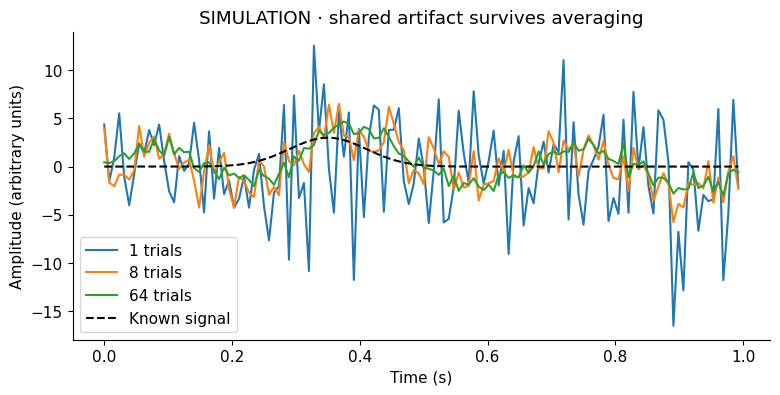

In [5]:
demo_t=np.linspace(0,1,128,endpoint=False)
demo_signal=3*np.exp(-.5*((demo_t-.35)/.06)**2)
demo_trials=demo_signal+rng.normal(0,5,(128,128))
shared_artifact=2*np.sin(2*np.pi*3*demo_t)
fig,ax=plt.subplots()
for count in [1,8,64]:
    ax.plot(demo_t,demo_trials[:count].mean(0)+shared_artifact,label=f'{count} trials')
ax.plot(demo_t,demo_signal,'k--',label='Known signal')
ax.set(xlabel='Time (s)',ylabel='Amplitude (arbitrary units)',title='SIMULATION · shared artifact survives averaging')
ax.legend();plt.show()

**Read the result.** Look for reduced random fluctuation as the trial count increases, but persistent deviation from the known signal. More data does not automatically cure systematic measurement error.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

An EEG channel measures a voltage difference, not an absolute brain potential. Synchronized postsynaptic currents from many similarly oriented neurons contribute to scalp EEG; skull and tissue spread their fields. A channel is therefore not a direct readout of one cortical source.

For samples $x_c[n]$ from channel $c$, time is $t_n=n/f_s$. Sampling at $f_s$ Hz only represents frequencies below $f_s/2$ without aliasing, assuming appropriate analog anti-alias filtering. MNE stores EEG in **volts**: $1\,\mu V=10^{-6}\,V$.

`Raw` holds continuous channels × time; `Epochs` holds trials × channels × time; `Evoked` is a trial average. `Info` carries units, sampling frequency, channel types and sensor geometry. Event sample indices are integer positions, while annotations use seconds. Confusing these conventions shifts labels away from physiology.

The controlled waveform below is explicitly synthetic: it checks your environment and units, not BCI performance. Real recordings begin in notebook 01.

## Build an inspectable recording
Make a known 10 Hz oscillation plus noise so you can verify the time and frequency axes.

The simulated voltage is expressed in volts, even though its amplitude is easier to discuss in microvolts. `create_info` supplies channel type and sampling rate; `RawArray` attaches those meanings to the array. We use a standard montage only to label sensor geometry. Inspect the array shape and sampling metadata before interpreting the plotted waveform.

/tmp/ipykernel_452850/4232803724.py:6: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  raw.set_montage('standard_1020')


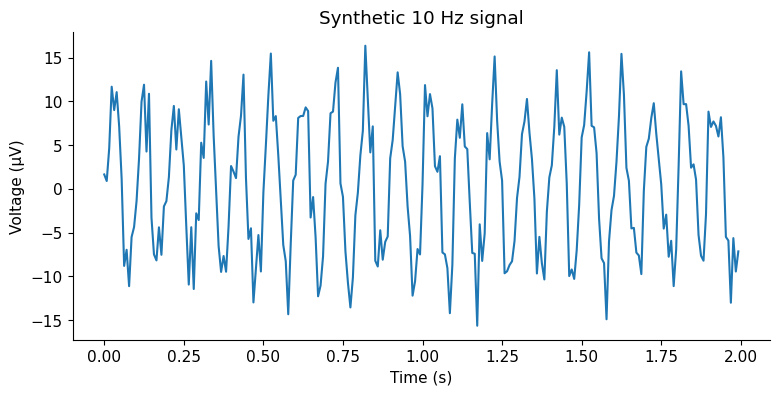

In [6]:
sfreq = 128.0
t = np.arange(1280) / sfreq
wave = 10e-6 * np.sin(2*np.pi*10*t)
raw = mne.io.RawArray(np.vstack([wave, wave + rng.normal(0, 3e-6, len(t))]),
                      mne.create_info(['C3','C4'], sfreq, 'eeg'))
raw.set_montage('standard_1020')
fig, ax = plt.subplots()
ax.plot(t[:256], raw.get_data()[1,:256]*1e6)
ax.set(xlabel='Time (s)', ylabel='Voltage (µV)', title='Synthetic 10 Hz signal')
plt.show()
assert raw.get_data().shape == (2,1280)

### Inspect and interpret

Count approximately ten cycles in one second of the plotted waveform. If the period is unexpected, inspect the sampling metadata and the time vector separately. Noise changes individual peaks, but the intended oscillation period is 0.1 s.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## From events to averages
The third event column is a condition code. Baseline subtraction removes each epoch’s pre-event mean; it is not a high-pass filter.

The event code is mapped to a named condition. `Epochs` extracts one segment for each event, and `average` reduces the trial axis. The simulated oscillation is not a physiological ERP; its purpose is to make the data transformations visible.

Raw: (2, 1280) Epochs: (4, 2, 104)


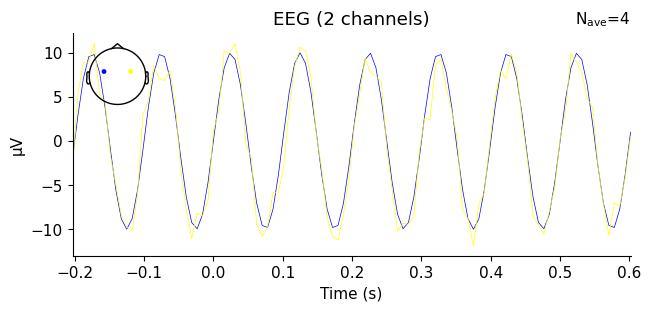

In [7]:
events = np.array([[256,0,1],[512,0,1],[768,0,1],[1024,0,1]])
epochs = mne.Epochs(raw, events, {'cue':1}, -0.2, 0.6, baseline=(-0.2,0), preload=True)
print('Raw:', raw.get_data().shape, 'Epochs:', epochs.get_data().shape)
epochs.average().plot(show=False)
plt.show()

### Inspect and interpret

Read `epochs.get_data().shape` as trials, channels and times. Check the first and last values in `epochs.times`. Explain what information is lost when the trials are averaged.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · Unit conversion

Implement `to_volts` below and test positive, negative and zero values. Explain why the plotting label alone cannot repair incorrectly stored units.

In [8]:
def to_volts(values_uV):
    # TODO: convert a NumPy-compatible input from microvolts to volts.
    return None

In [9]:
answer=to_volts(np.array([-10.,0.,25.]))
if answer is not None:
    np.testing.assert_allclose(answer,[-1e-5,0,25e-6]); print('Unit checks passed.')
else:
    print('Exercise pending: implement to_volts and rerun this cell.')

Exercise pending: implement to_volts and rerun this cell.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Sampling calculation

At 250 Hz, find the sample index corresponding to 0.8 s. State whether your convention rounds, floors or interpolates for times off the grid.

In [10]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Axis detective

Starting from `toy_epochs`, compute one scalar per trial. Then compute one waveform per channel. Write the resulting shapes before running the code.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · MNE object inspection

Print the sampling rate, channel names and first five times of the recording in this notebook. Locate where montage positions are stored.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · Averaging experiment

Repeat the simulation for trial counts 1, 4, 16 and 64. Plot error against count with and without the shared artifact. Explain which part follows the square-root rule.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

Draw the Raw → Epochs → Evoked sequence. Label what information is added or discarded at each arrow. Submit the drawing and one example of a plausible but incorrect axis operation.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[MNE data structures](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Continue to notebook 01.

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.